# Imports

In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.5 MB/s eta 0:00:00


## Google Drive setup
Mount Drive **before** anything else so checkpoints are safe even if Colab disconnects mid-training.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


In [3]:
import torch
from torchvision import transforms
from medmnist import BloodMNIST
from collections import Counter
import matplotlib.pyplot as plt

# resize + normalize

In [4]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset

In [5]:
train_data = BloodMNIST(split='train', transform=data_transform, download=True)
val_data   = BloodMNIST(split='val', transform=data_transform, download=True)
test_data  = BloodMNIST(split='test', transform=data_transform, download=True)

100%|██████████| 35.5M/35.5M [00:02<00:00, 12.5MB/s]


In [6]:
print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

Train size: 11959
Validation size: 1712
Test size: 3421


# Imbalance

In [7]:
labels = [int(label) if isinstance(label, (int, float)) else int(label[0]) for _, label in train_data]


class_counts = Counter(labels)


for cls, count in class_counts.items():
    print(f"Class {cls}: {count} samples")

Class 7: 1643 samples
Class 3: 2026 samples
Class 6: 2330 samples
Class 2: 1085 samples
Class 1: 2181 samples
Class 5: 993 samples
Class 0: 852 samples
Class 4: 849 samples


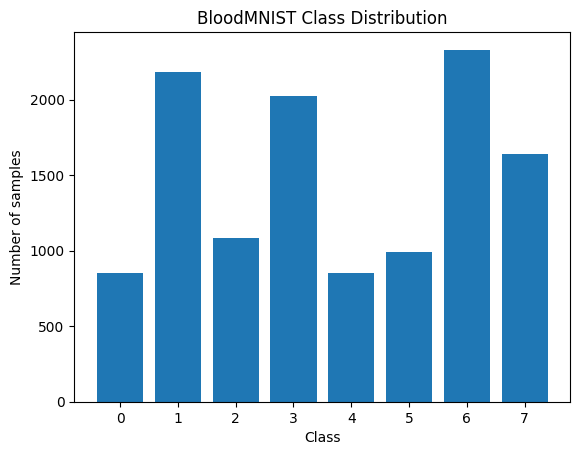

In [8]:
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("BloodMNIST Class Distribution")
plt.show()

# Class weights

In [9]:
total = sum(class_counts.values())
weights = [total / class_counts[i] for i in range(len(class_counts))]
class_weights = torch.tensor(weights, dtype=torch.float)


criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)

Class weights: tensor([14.0364,  5.4833, 11.0221,  5.9028, 14.0860, 12.0433,  5.1326,  7.2788])


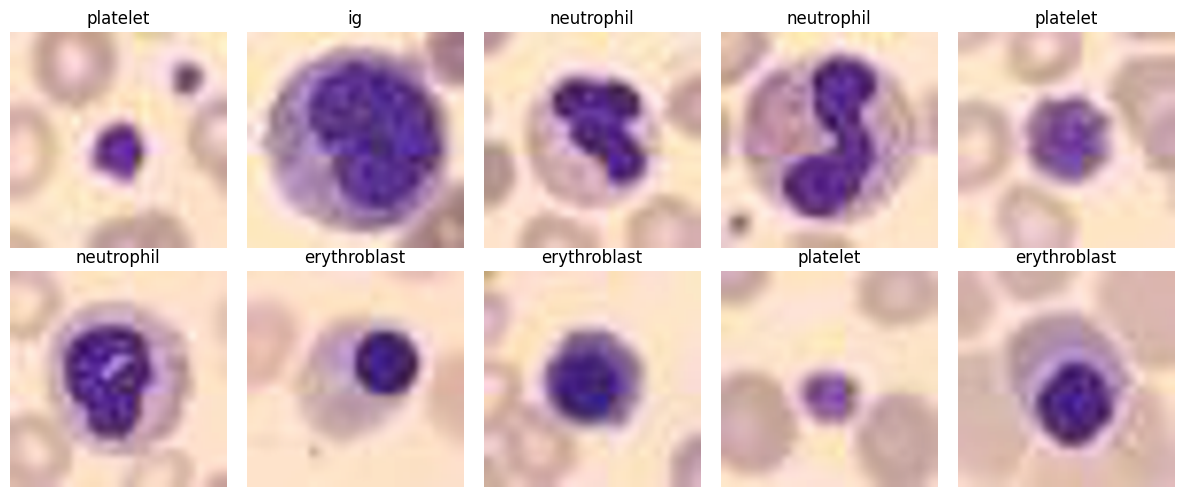

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Mean & std (same as your transform)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Class names
CLASS_NAMES = ['basophil','eosinophil','erythroblast','ig','lymphocyte',
               'monocyte','neutrophil','platelet']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_data[i]

    # FIX 1: label shape (important)
    if isinstance(label, (list, tuple, np.ndarray)):
        label = label[0]

    # FIX 2: convert image
    img = img.cpu().numpy().transpose(1, 2, 0)

    # FIX 3: denormalize
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[int(label)])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Training Setup

# Fine-Tuning: ResNet-18 | EfficientNet-B0 | ConvNeXt-Tiny

In [11]:
!pip install -q timm


## Imports & Device

In [12]:
import time, copy, os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import (
    resnet18,        ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    convnext_tiny,   ConvNeXt_Tiny_Weights,
    vit_b_16,        ViT_B_16_Weights,
)
import matplotlib.pyplot as plt
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 8
BATCH_SIZE  = 64
EPOCHS      = 10          # reduced from 15 — early stopping handles the rest
LR          = 3e-4
PATIENCE    = 3           # stop if val loss doesn't improve for 3 epochs

# Checkpoint directory — saved to Google Drive so Colab disconnects don't lose progress
CHECKPOINT_DIR = '/content/drive/MyDrive/bloodmnist_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CLASS_NAMES = ['basophil','eosinophil','erythroblast','ig','lymphocyte',
               'monocyte','neutrophil','platelet']

print('Device:', DEVICE)
print('Checkpoint dir:', CHECKPOINT_DIR)


Device: cuda
Checkpoint dir: /content/drive/MyDrive/bloodmnist_checkpoints


## DataLoaders

In [13]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches  →  train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')


Batches  →  train: 187  val: 27  test: 54


## Weighted Loss Function
Re-use the `class_weights` computed earlier to handle BloodMNIST's class imbalance.

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
print('Class weights:', class_weights.numpy().round(2))


Class weights: [14.04  5.48 11.02  5.9  14.09 12.04  5.13  7.28]


## Model Builders
All three models are loaded with **ImageNet pre-trained weights**; only the classification head is replaced.
Full fine-tuning (all layers unfrozen) is used so every layer adapts to the medical domain.

In [15]:
def build_resnet18(num_classes=NUM_CLASSES):
    """ResNet-18: replace final FC layer."""
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


def build_efficientnet_b0(num_classes=NUM_CLASSES):
    """EfficientNet-B0: replace classifier head."""
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m


def build_convnext_tiny(num_classes=NUM_CLASSES):
    """ConvNeXt-Tiny: replace classifier head."""
    m = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    m.classifier[2] = nn.Linear(m.classifier[2].in_features, num_classes)
    return m



## Training & Evaluation Helpers

In [16]:
def run_epoch(model, loader, optimizer, criterion, training):
    model.train() if training else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.squeeze().long().to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds_all.extend(logits.argmax(1).cpu().tolist())
            labels_all.extend(labels.cpu().tolist())

    n        = len(loader.dataset)
    avg_loss = total_loss / n
    acc      = sum(p == l for p, l in zip(preds_all, labels_all)) / n
    bal_acc  = balanced_accuracy_score(labels_all, preds_all)

    return avg_loss, acc, bal_acc, preds_all, labels_all


def ckpt_path(name, epoch=None):
    tag = f'epoch{epoch:02d}' if epoch else 'best'
    safe = name.lower().replace('/', '_').replace('-', '')
    return os.path.join(CHECKPOINT_DIR, f'{safe}_{tag}.pth')


def fine_tune(name, model, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    model = model.to(DEVICE)

    head_params     = [p for n, p in model.named_parameters() if 'fc' in n or 'classifier' in n or 'heads' in n]
    backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n and 'classifier' not in n and 'heads' not in n]

    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': lr / 10},
        {'params': head_params,     'lr': lr},
    ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {k: [] for k in ['tr_loss', 'tr_acc', 'val_loss', 'val_acc']}
    best_acc  = 0
    no_improve = 0
    start_epoch = 1

    best_ckpt = ckpt_path(name)

    # Resume
    for ep in range(epochs, 0, -1):
        ep_ckpt = ckpt_path(name, ep)
        if os.path.exists(ep_ckpt):
            print(f'  Resuming {name} from epoch {ep}')
            state = torch.load(ep_ckpt, map_location=DEVICE, weights_only=False)

            model.load_state_dict(state['model'])
            optimizer.load_state_dict(state['optimizer'])
            scheduler.load_state_dict(state['scheduler'])
            history    = state['history']
            best_acc   = state.get('best_acc', 0)   # FIXED
            no_improve = state['no_improve']
            start_epoch = ep + 1
            break

    if start_epoch > epochs:
        model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE)['model'])
        return model, history

    print(f'\n{"="*60}')
    print(f'  Fine-tuning  {name}')
    print(f'{"="*60}')

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, optimizer, criterion, training=True)
        vl_loss, vl_acc, _, _ = run_epoch(model, val_loader, optimizer, criterion, training=False)

        scheduler.step()

        # Store history
        history['tr_loss'].append(tr_loss)
        history['tr_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)


        #  KEY CHANGE: based on ACCURACY
        improved = vl_acc > best_acc

        if improved:
            best_acc = vl_acc
            no_improve = 0
            torch.save({'model': model.state_dict()}, best_ckpt)
        else:
            no_improve += 1

        # Save checkpoint
        torch.save({
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'history':   history,
            'best_acc':  best_acc,   #
            'no_improve': no_improve,
        }, ckpt_path(name, epoch))

        print(f'  Epoch {epoch:02d}/{epochs} | '
              f'Train Loss {tr_loss:.4f} | '
              f'Train Acc {tr_acc:.3f} | '
              f'Val Loss {vl_loss:.4f} | '
              f'Val Acc {vl_acc:.3f} | '

              f'{" best" if improved else f"no imp {no_improve}/{patience}"} | '
              f'{time.time()-t0:.1f}s')

        if no_improve >= patience:
            print(f'  Early stopping triggered at epoch {epoch}.')
            break

    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE)['model'])
    print(f'  Best val acc: {best_acc:.4f}  |  Checkpoint: {best_ckpt}')

    return model, history

## Fine-Tune All Three Models

In [17]:
# Mount Google Drive — checkpoints survive Colab disconnections
from google.colab import drive
drive.mount('/content/drive')

resnet_model, resnet_hist = fine_tune('ResNet-18',      build_resnet18())
effnet_model, effnet_hist = fine_tune('EfficientNet-B0', build_efficientnet_b0())
convnext_model, convnext_hist = fine_tune('ConvNeXt-Tiny', build_convnext_tiny())



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


  Resuming ResNet-18 from epoch 10
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 113MB/s] 


  Resuming EfficientNet-B0 from epoch 10
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 174MB/s]


  Resuming ConvNeXt-Tiny from epoch 10


## Test-Set Evaluation

In [18]:
print(f'\n{"Model":<20} {"Accuracy":>10}')
print('-' * 32)

test_results = {}

for name, model in [
    ('ResNet-18', resnet_model),
    ('EfficientNet-B0', effnet_model),
    ('ConvNeXt-Tiny', convnext_model),
]:

    _, acc, _, preds, labels = run_epoch(
        model, test_loader, None, criterion, training=False
    )

    test_results[name] = dict(acc=acc, preds=preds, labels=labels)

    print(f'{name:<20} {acc:>10.4f}')


Model                  Accuracy
--------------------------------
ResNet-18                0.9597
EfficientNet-B0          0.9646
ConvNeXt-Tiny            0.9754


## Per-Class Classification Reports

In [19]:
for name, res in test_results.items():
    print(f'\n── {name} ──')
    print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))



── ResNet-18 ──
              precision    recall  f1-score   support

    basophil       0.92      0.95      0.94       244
  eosinophil       1.00      0.99      0.99       624
erythroblast       0.98      0.96      0.97       311
          ig       0.90      0.92      0.91       579
  lymphocyte       0.95      0.96      0.96       243
    monocyte       0.93      0.92      0.93       284
  neutrophil       0.98      0.96      0.97       666
    platelet       0.99      1.00      1.00       470

    accuracy                           0.96      3421
   macro avg       0.96      0.96      0.96      3421
weighted avg       0.96      0.96      0.96      3421


── EfficientNet-B0 ──
              precision    recall  f1-score   support

    basophil       0.92      0.97      0.94       244
  eosinophil       0.99      1.00      0.99       624
erythroblast       0.99      0.97      0.98       311
          ig       0.94      0.89      0.91       579
  lymphocyte       0.94      0.98     

## Confusion Matrices

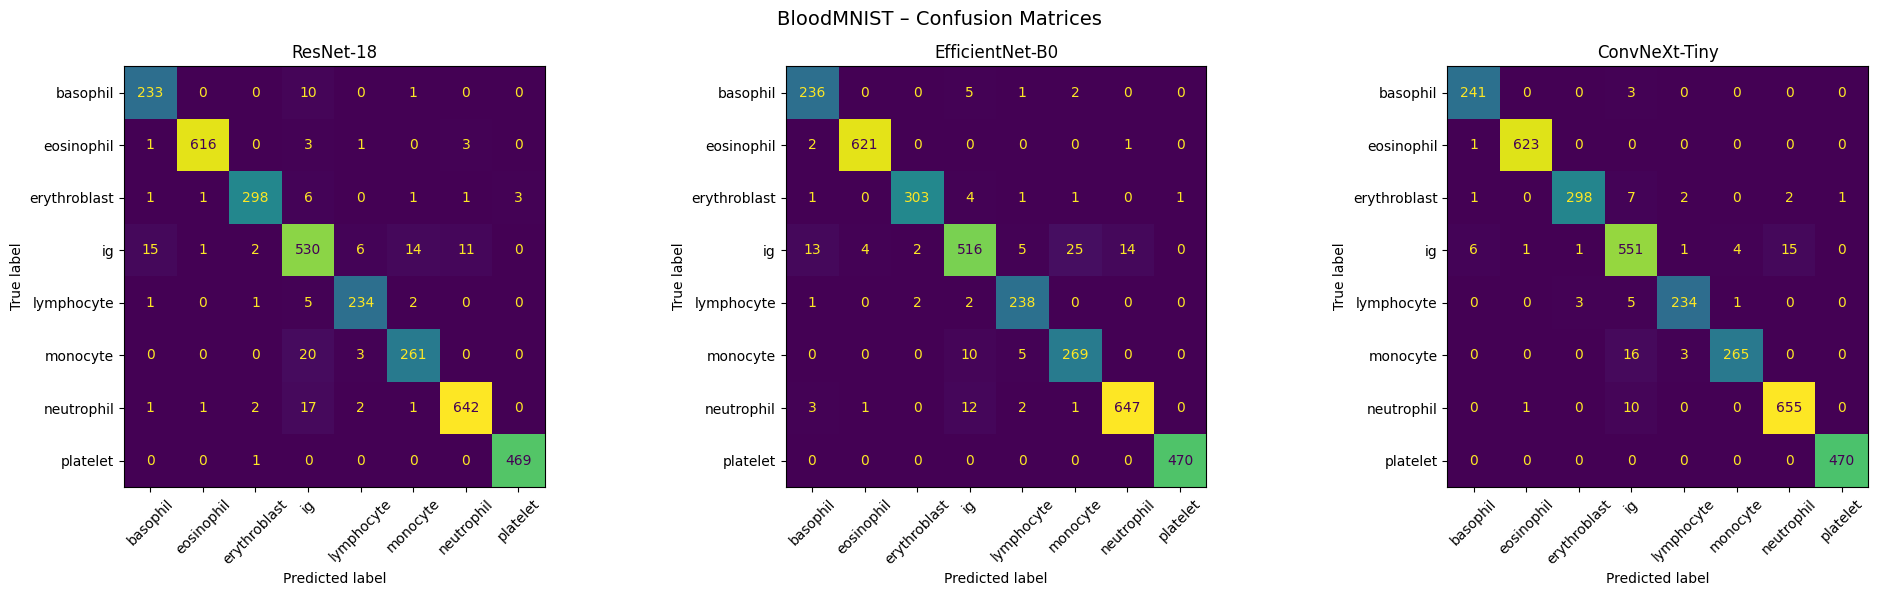

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name)
plt.suptitle('BloodMNIST – Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()


## Learning Curves

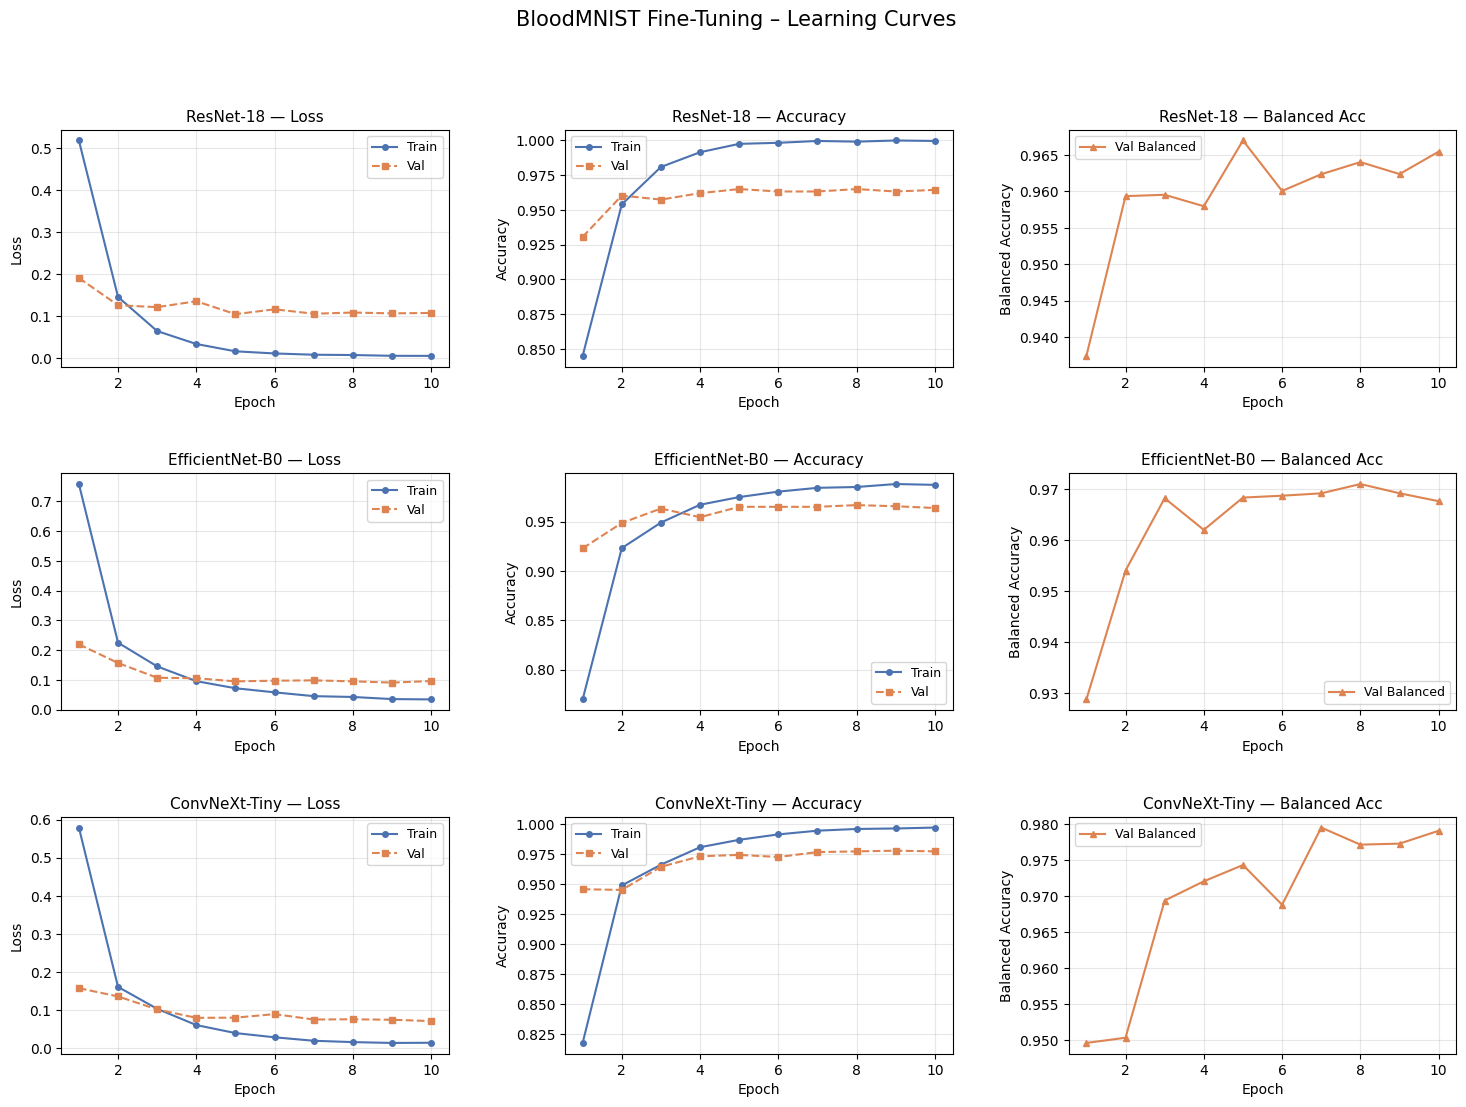

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

histories = {
    'ResNet-18':      resnet_hist,
    'EfficientNet-B0': effnet_hist,
    'ConvNeXt-Tiny':  convnext_hist,
}

epochs = range(1, EPOCHS + 1)
model_names = list(histories.keys())
colors = {'train': '#4C72B0', 'val': '#DD8452'}  # blue for train, orange for val

fig = plt.figure(figsize=(18, 12))
fig.suptitle('BloodMNIST Fine-Tuning – Learning Curves', fontsize=15, y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.3)

for row, (mname, hist) in enumerate(histories.items()):
    # --- Loss (train + val overlaid) ---
    ax_loss = fig.add_subplot(gs[row, 0])
    ax_loss.plot(epochs, hist['tr_loss'],  color=colors['train'], marker='o', ms=4, label='Train')
    ax_loss.plot(epochs, hist['val_loss'], color=colors['val'],   marker='s', ms=4, label='Val', linestyle='--')
    ax_loss.set_title(f'{mname} — Loss',     fontsize=11)
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=9); ax_loss.grid(alpha=0.3)

    # --- Accuracy ---
    ax_acc = fig.add_subplot(gs[row, 1])
    ax_acc.plot(epochs, hist['tr_acc'],  color=colors['train'], marker='o', ms=4, label='Train')
    ax_acc.plot(epochs, hist['val_acc'], color=colors['val'],   marker='s', ms=4, label='Val', linestyle='--')
    ax_acc.set_title(f'{mname} — Accuracy', fontsize=11)
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=9); ax_acc.grid(alpha=0.3)

    # --- Balanced Accuracy ---
    ax_bal = fig.add_subplot(gs[row, 2])
    ax_bal.plot(epochs, hist['val_bal_acc'], color=colors['val'], marker='^', ms=4, label='Val Balanced')
    ax_bal.set_title(f'{mname} — Balanced Acc', fontsize=11)
    ax_bal.set_xlabel('Epoch'); ax_bal.set_ylabel('Balanced Accuracy')
    ax_bal.legend(fontsize=9); ax_bal.grid(alpha=0.3)

plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

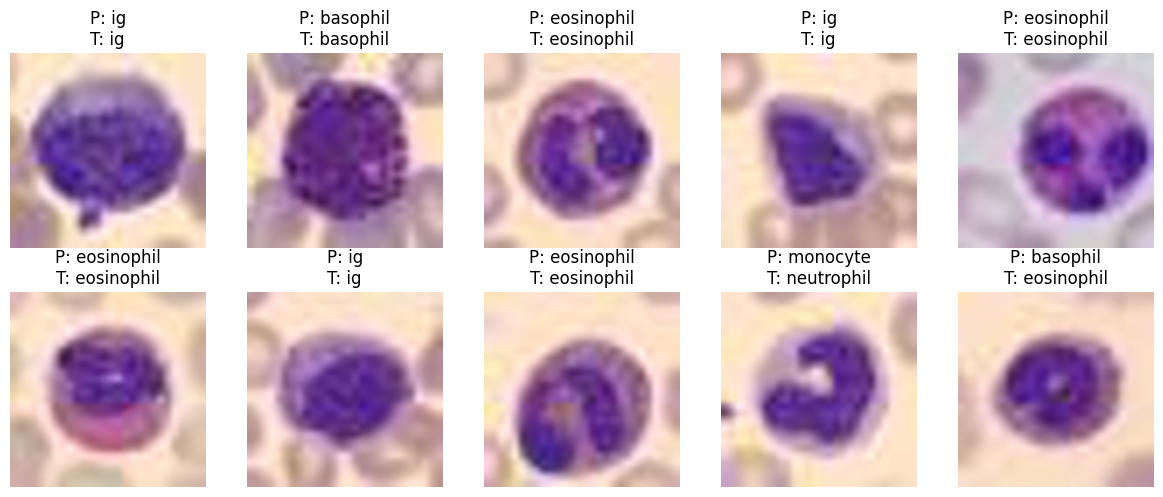

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Mean & std (same as before)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Get a batch from test loader
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# Get predictions
model = resnet_model
model.eval()

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().numpy().transpose(1, 2, 0)

    # Denormalize
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    true_label = int(labels[i]) if isinstance(labels[i], (int,float)) else int(labels[i][0])
    pred_label = int(preds[i])

    ax.imshow(img)
    ax.set_title(f"P: {CLASS_NAMES[pred_label]}\nT: {CLASS_NAMES[true_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

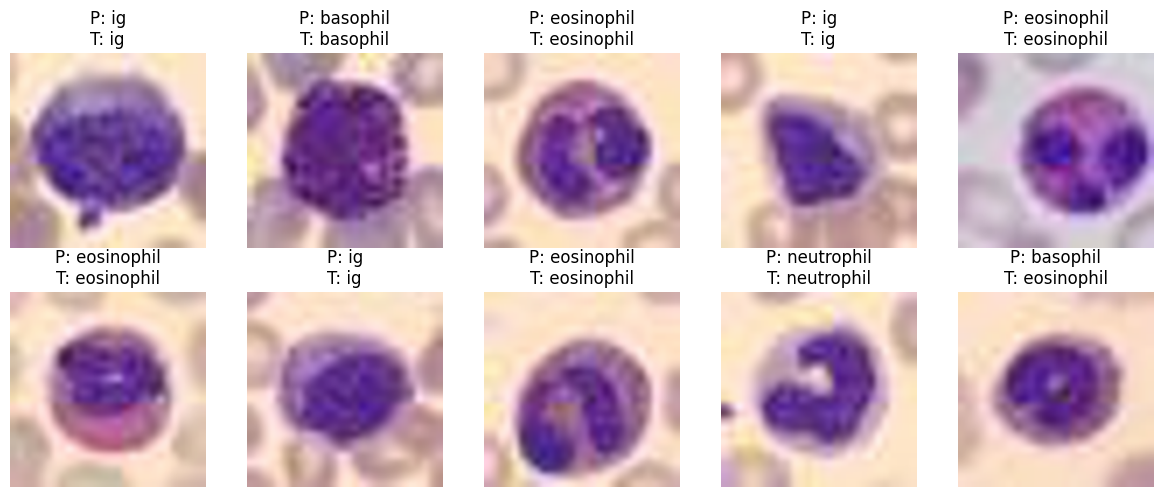

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Mean & std (same as before)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Get a batch from test loader
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# Get predictions
model =effnet_model
model.eval()

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().numpy().transpose(1, 2, 0)

    # Denormalize
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    true_label = int(labels[i]) if isinstance(labels[i], (int,float)) else int(labels[i][0])
    pred_label = int(preds[i])

    ax.imshow(img)
    ax.set_title(f"P: {CLASS_NAMES[pred_label]}\nT: {CLASS_NAMES[true_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

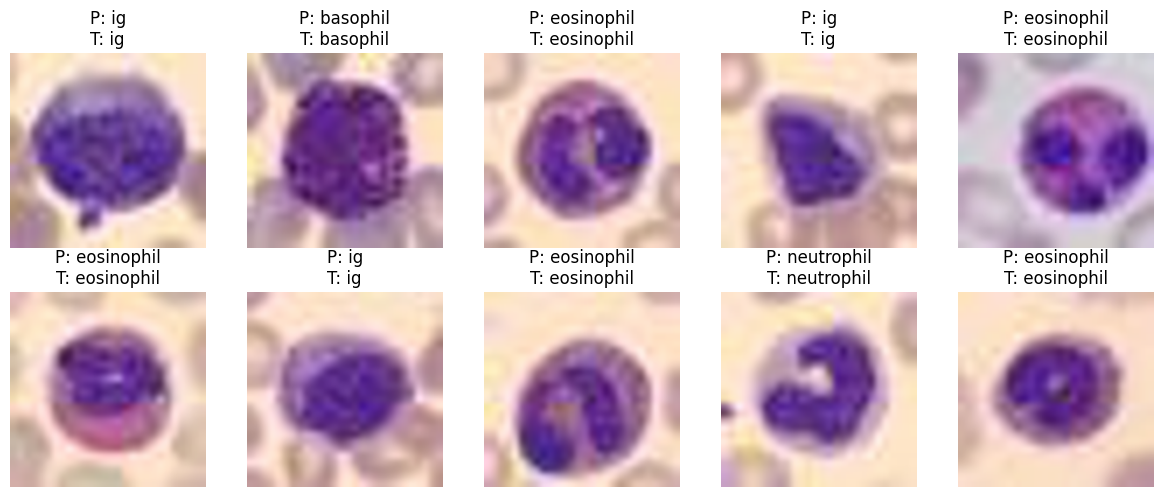

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Mean & std (same as before)
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

# Get a batch from test loader
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# Get predictions
model =convnext_model
model.eval()

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

# Plot
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().numpy().transpose(1, 2, 0)

    # Denormalize
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    true_label = int(labels[i]) if isinstance(labels[i], (int,float)) else int(labels[i][0])
    pred_label = int(preds[i])

    ax.imshow(img)
    ax.set_title(f"P: {CLASS_NAMES[pred_label]}\nT: {CLASS_NAMES[true_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Save Checkpoints

In [26]:
# Best checkpoints are already saved to Drive during training.
# This cell also downloads them directly to your browser.
from google.colab import files
import shutil

for fname in ['resnet18bloodmnist_best.pth',
               'efficientnetb0_best.pth',
               'convnexttiny_best.pth',
             ]:
    src = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, fname)
        files.download(fname)
        print(f'Downloaded: {fname}')
    else:
        print(f'Not found (training may not have completed): {fname}')


Not found (training may not have completed): resnet18bloodmnist_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: efficientnetb0_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: convnexttiny_best.pth


In [27]:
import torch

torch.save(train_data, '/content/drive/MyDrive/bloodmnist_train.pt')
torch.save(val_data,   '/content/drive/MyDrive/bloodmnist_val.pt')
torch.save(test_data,  '/content/drive/MyDrive/bloodmnist_test.pt')

In [28]:
import pandas as pd
df=pd.DataFrame(test_results)

df.to_csv("Dl_1.csv", index=False)

In [29]:
import os
print(os.getcwd())

/content


In [30]:
import os
print(os.getcwd())  # usually outputs: /content
print(os.listdir())  # lists all files in the current folder

/content
['.config', 'convnexttiny_best.pth', 'learning_curves.png', 'drive', 'efficientnetb0_best.pth', 'Dl_1.csv', 'sample_data']


In [31]:
from google.colab import files
files.download("Dl_1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>